In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("IPL.csv")


/tmp/ipython-input-645713066.py:5: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("IPL.csv")


In [ ]:
df.shape


(278205, 64)

In [ ]:
df.columns


Index(['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings',
       'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter',
       'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball',
       'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
       'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind',
       'player_out', 'fielders', 'runs_target', 'review_batter',
       'team_reviewed', 'review_decision', 'umpire', 'umpires_call',
       'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner',
       'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season',
       'gender', 'team_type', 'superover_winner', 'result_type', 'method',
       'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number',
       'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs',
       'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter',
       'striker_out'],
      dtype='object')

In [ ]:
df.isna().sum()


,0
Unnamed: 0,0
match_id,0
date,0
match_type,0
event_name,0
...,...
batter_balls,0
bowler_wicket,0
batting_partners,0
next_batter,264884


In [ ]:
df = df.drop_duplicates()

df = df.dropna(subset=[
    "match_id",
    "batter",
    "bowler",
    "batting_team",
    "bowling_team",
    "runs_total"
])

df["runs_total"] = pd.to_numeric(df["runs_total"], errors="coerce")
df["runs_batter"] = pd.to_numeric(df["runs_batter"], errors="coerce")
df["balls_faced"] = pd.to_numeric(df["balls_faced"], errors="coerce")
df = df.dropna(subset=["runs_total", "runs_batter"])
df = df.reset_index(drop=True)
df.to_csv("IPL_cleaned.csv", index=False)


In [ ]:
numeric_cols = ["runs_total", "runs_batter", "balls_faced", "team_runs", "team_balls", "team_wicket"]

bounds = {
    "runs_total": (0, 36),
    "runs_batter": (0, 36),
    "balls_faced": (0, 120),
    "team_runs": (0, 300),
    "team_balls": (0, 120),
    "team_wicket": (0, 10)
}

outliers_dict = {}

for col in numeric_cols:
    lower, upper = bounds[col]
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outliers_dict[col] = outliers
    print(f"Column: {col}")
    print(f"Number of outliers: {len(outliers)}")
    if len(outliers) > 0:
        print(outliers[[col, "match_id", "batter", "bowler", "batting_team", "bowling_team"]].head())
    print("-"*50)

all_outliers = pd.concat(outliers_dict.values()).drop_duplicates()
all_outliers.to_csv("IPL_outliers.csv", index=False)
print("All outliers saved as IPL_outliers.csv")

Column: runs_total
Number of outliers: 0
--------------------------------------------------
Column: runs_batter
Number of outliers: 0
--------------------------------------------------
Column: balls_faced
Number of outliers: 0
--------------------------------------------------
Column: team_runs
Number of outliers: 0
--------------------------------------------------
Column: team_balls
Number of outliers: 1
       team_balls  match_id       batter   bowler         batting_team  \
39090         121    419155  S Badrinath  A Nehra  Chennai Super Kings   

           bowling_team  
39090  Delhi Daredevils  
--------------------------------------------------
Column: team_wicket
Number of outliers: 0
--------------------------------------------------
All outliers saved as IPL_outliers.csv


In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv("IPL.csv")

df = df.drop_duplicates()
df = df.dropna(subset=["match_id", "batter", "bowler", "batting_team", "bowling_team", "runs_total"])

cols_to_drop = [
    "superover_winner",
    "review_batter",
    "review_decision",
    "team_reviewed",
    "umpire",
    "umpires_call",
    "method",
    "player_of_match",
    "next_batter",
    "striker_out",
    "result_type"
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

categorical_cols = df.select_dtypes(exclude=[np.number]).columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

df[categorical_cols] = df[categorical_cols].fillna("None")
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
df[numeric_cols] = df[numeric_cols].fillna(0)

df = df[
    (df["runs_total"] >= 0) & (df["runs_total"] <= 36) &
    (df["runs_batter"] >= 0) & (df["runs_batter"] <= 36) &
    (df["balls_faced"] >= 0) & (df["balls_faced"] <= 120) &
    (df["team_runs"] >= 0) & (df["team_runs"] <= 300) &
    (df["team_balls"] >= 0) & (df["team_balls"] <= 120) &
    (df["team_wicket"] >= 0) & (df["team_wicket"] <= 10)
]

df = df.reset_index(drop=True)

df.to_csv("IPL_final_cleaned_ML.csv", index=False)

print("Rows after cleaning:", df.shape[0])
print("Columns after cleaning:", df.shape[1])
print("Total missing values:", df.isna().sum().sum())


/tmp/ipython-input-2396580708.py:4: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("IPL.csv")


Rows after cleaning: 278204
Columns after cleaning: 53
Total missing values: 0


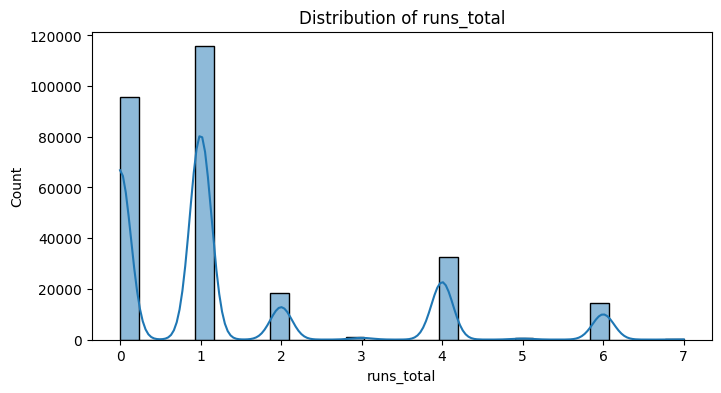

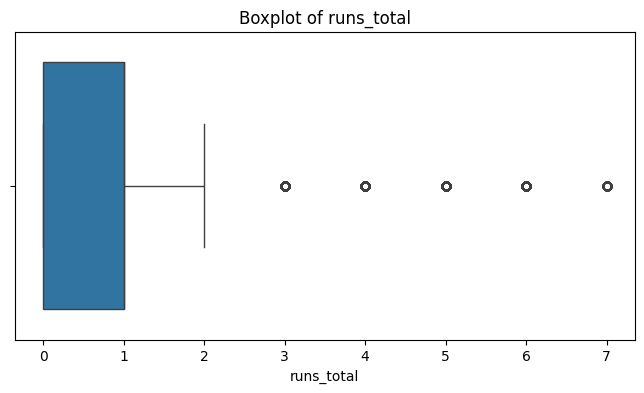

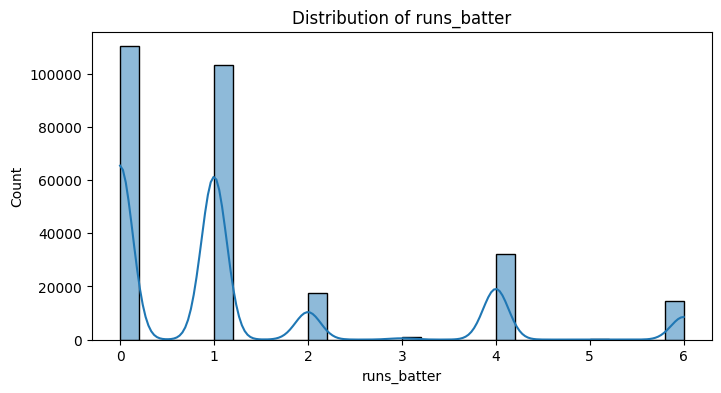

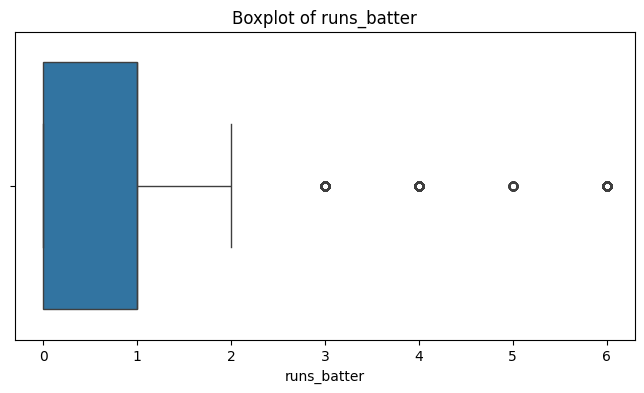

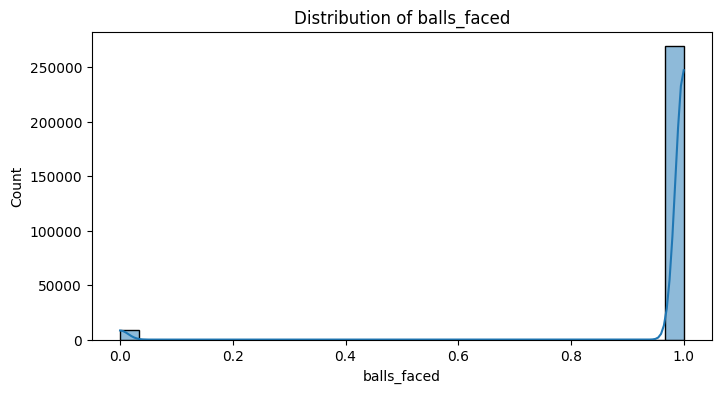

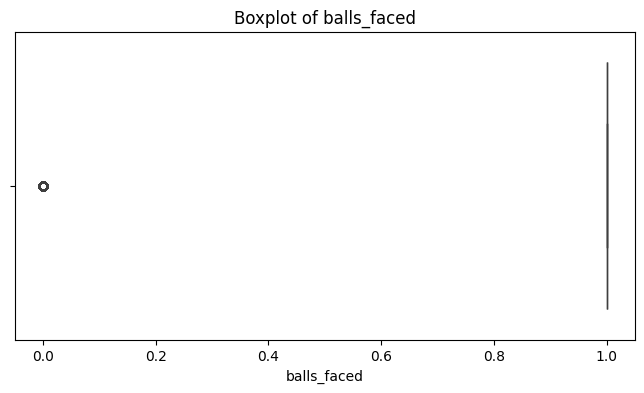

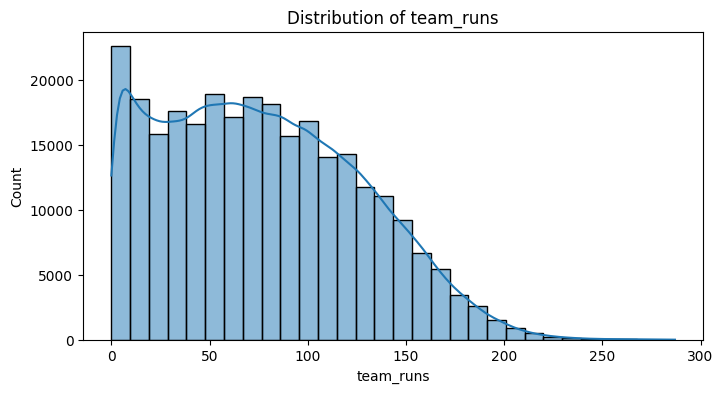

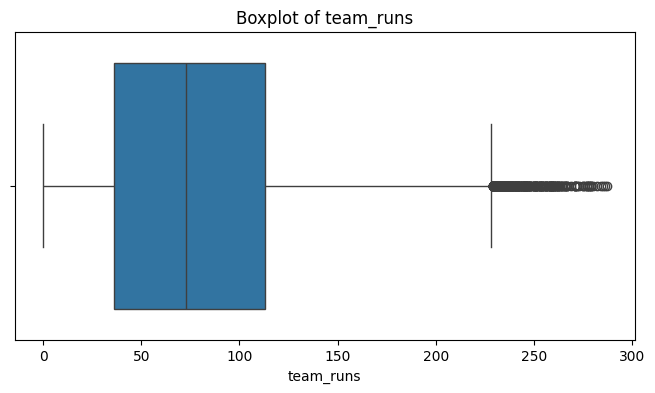

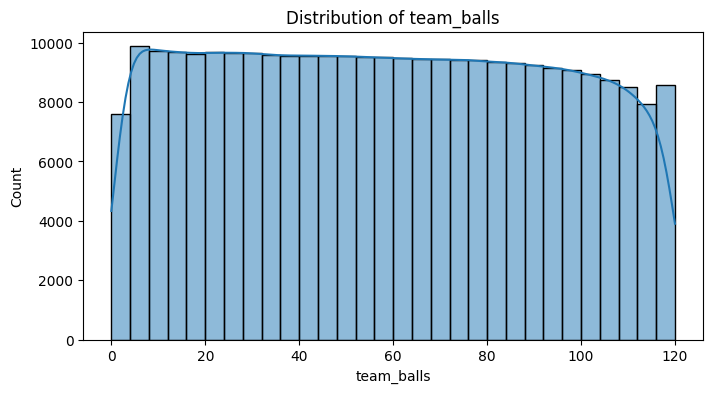

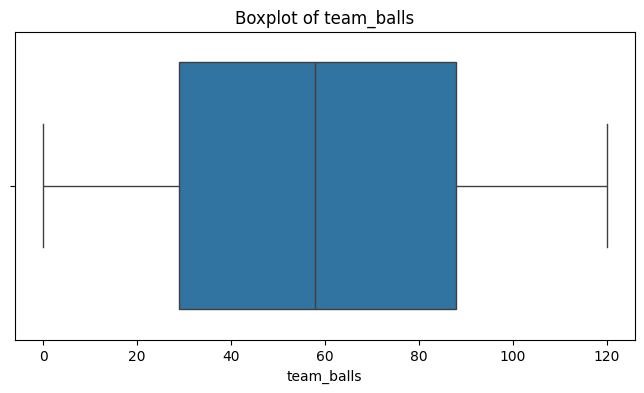

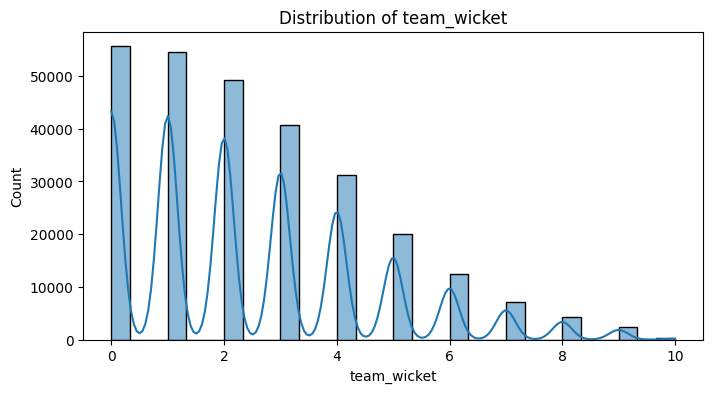

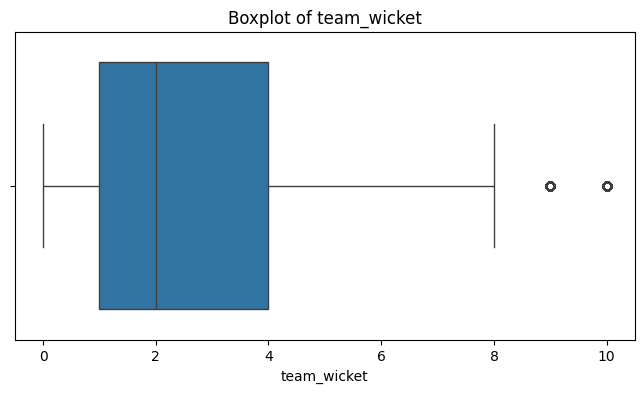

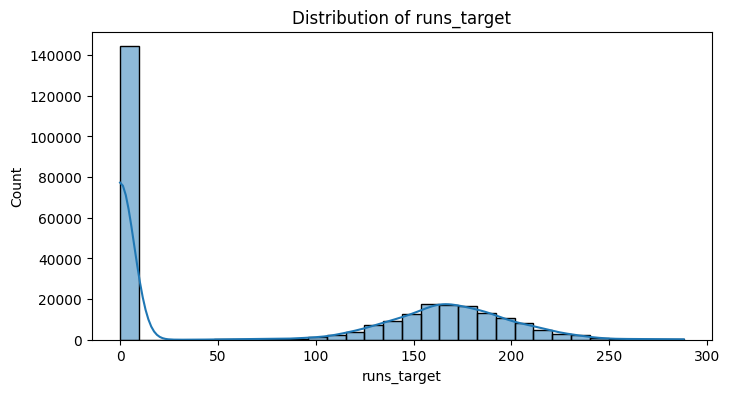

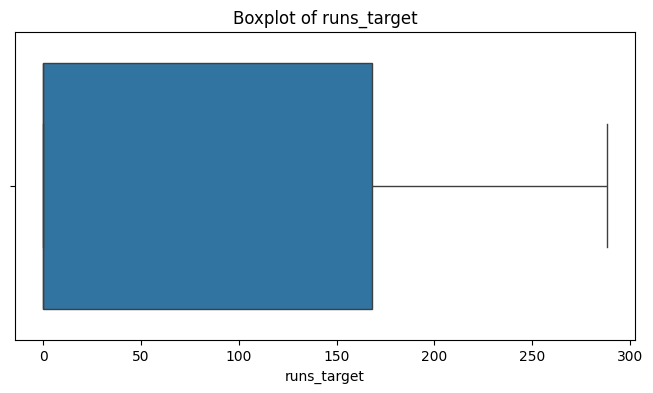

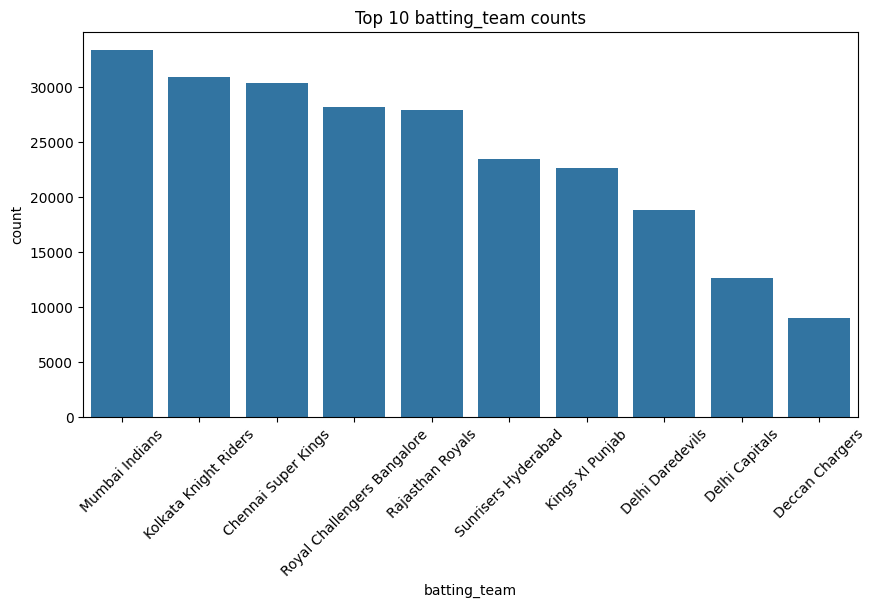

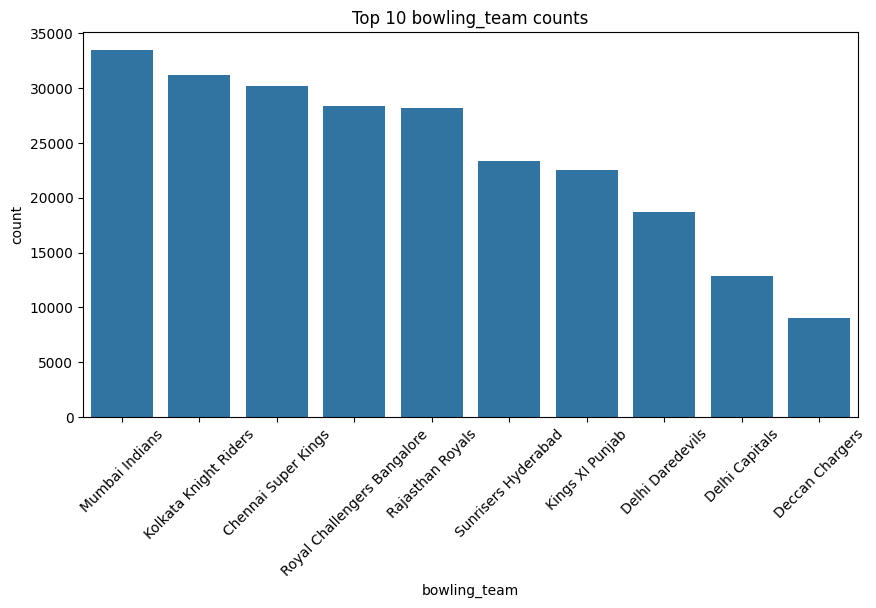

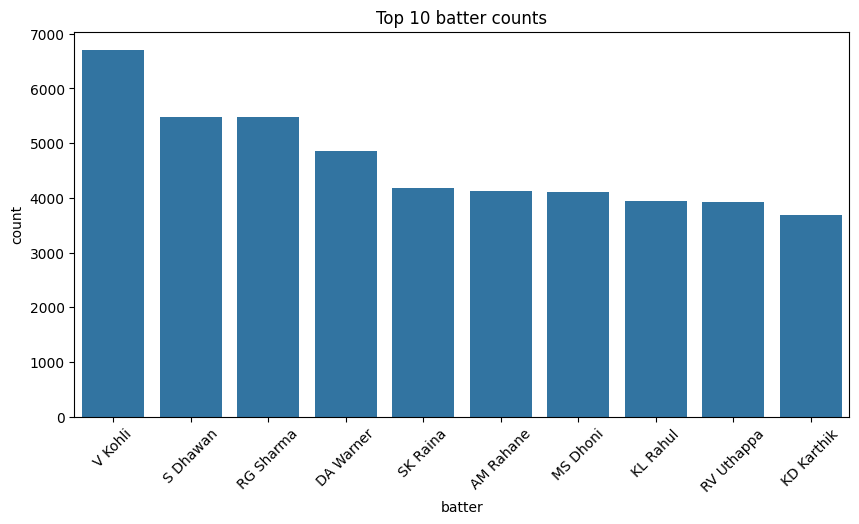

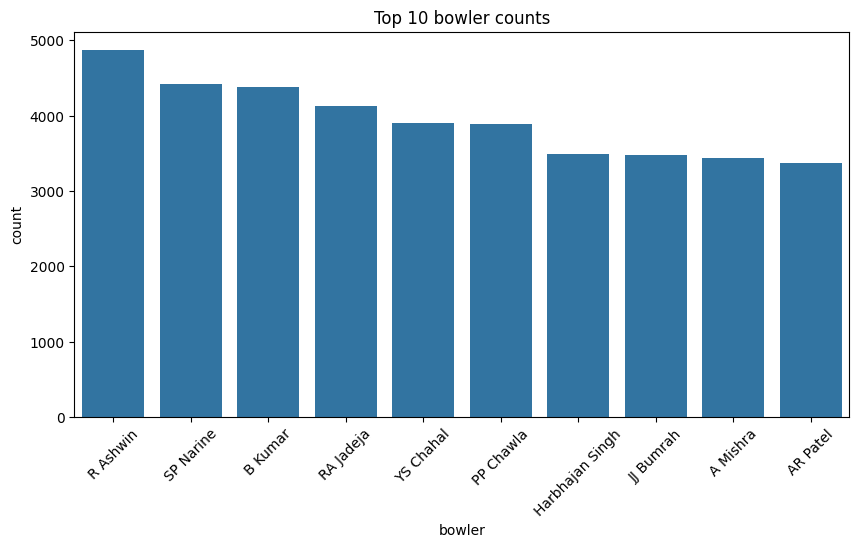

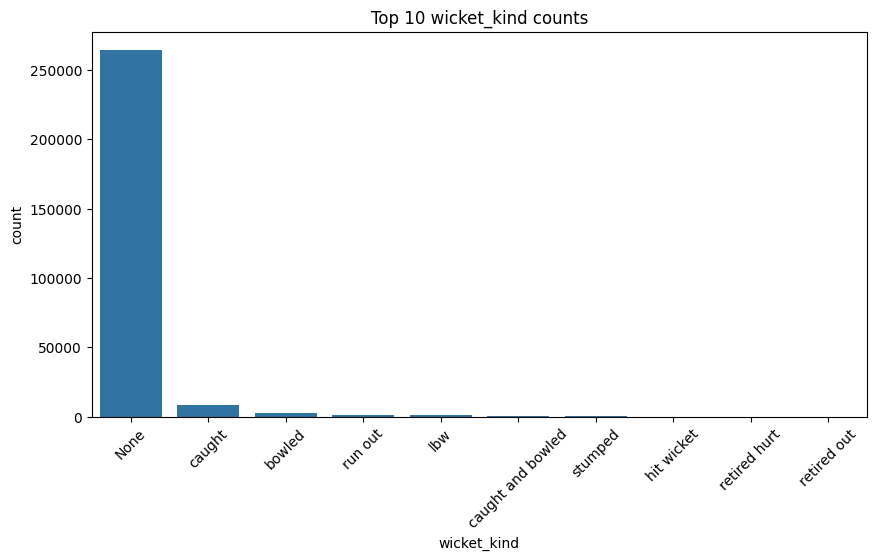

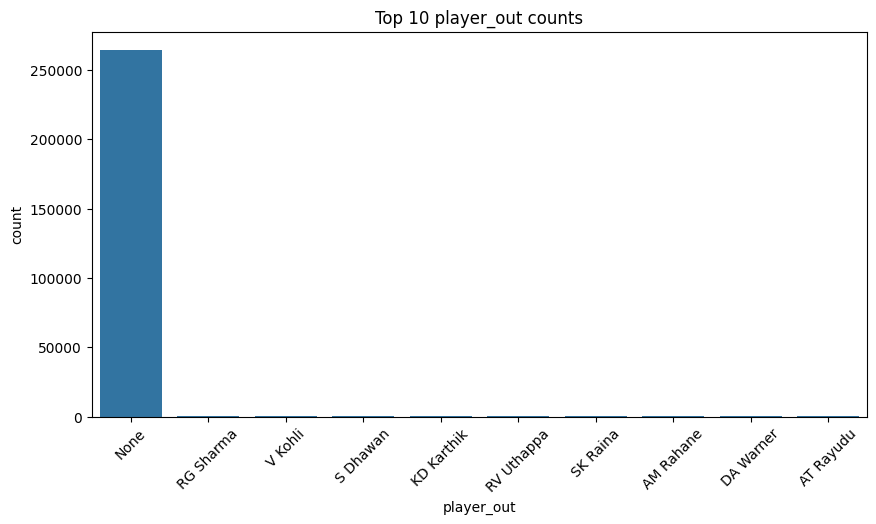

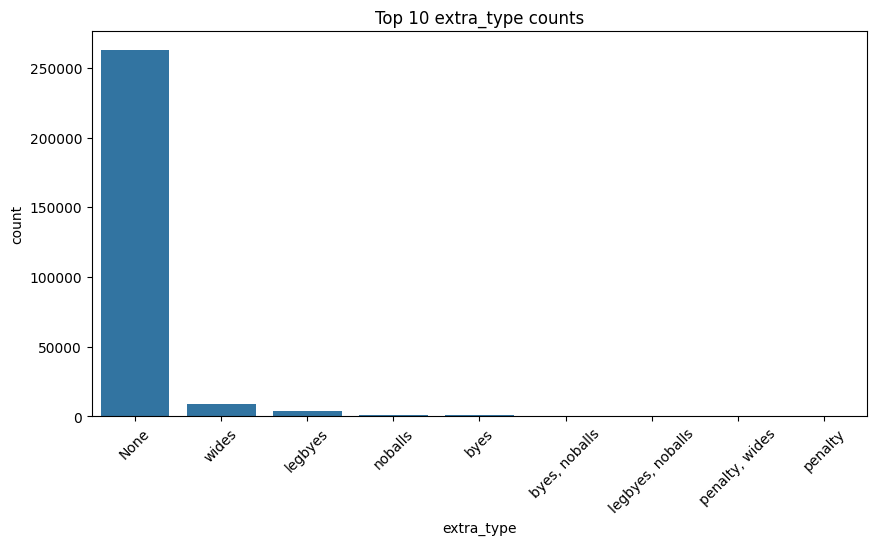

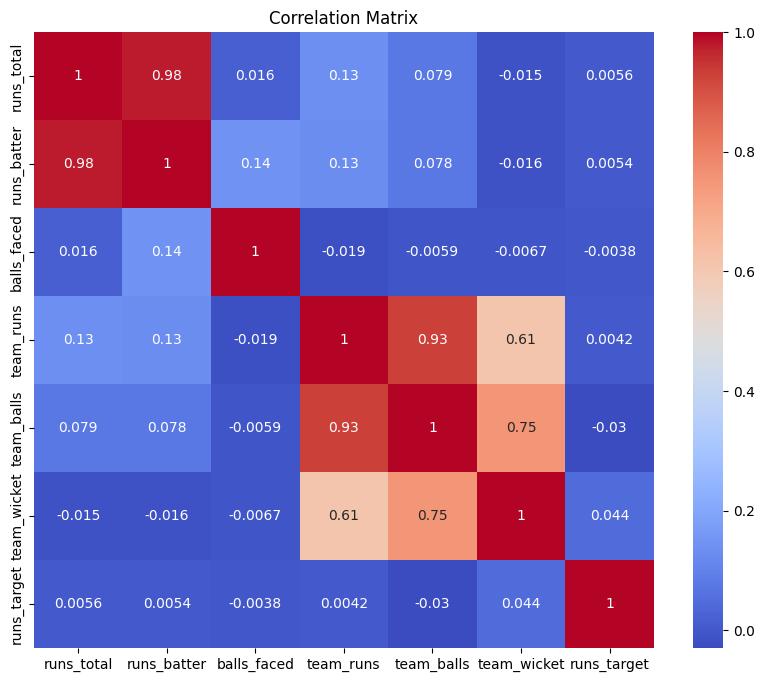

In [18]:
numeric_cols = ["runs_total", "runs_batter", "balls_faced", "team_runs", "team_balls", "team_wicket", "runs_target"]
categorical_cols = ["batting_team", "bowling_team", "batter", "bowler", "wicket_kind", "player_out", "extra_type"]

for col in numeric_cols:
    if col in df.columns:
        plt.figure(figsize=(8,4))
        sns.histplot(df[col], bins=30, kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

        plt.figure(figsize=(8,4))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot of {col}")
        plt.show()

for col in categorical_cols:
    if col in df.columns:
        plt.figure(figsize=(10,5))
        sns.countplot(data=df, x=col, order=df[col].value_counts().iloc[:10].index)
        plt.xticks(rotation=45)
        plt.title(f"Top 10 {col} counts")
        plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
